Decision Trees from Scratch

In [7]:
import numpy as np

def entropy(y):
  """ Calculate Entropy H(S) = -Σ p_i log2(p_i)"""
  _, counts = np.unique(y, return_counts=True)
  probs = counts / len(y)
  return -np.sum(probs * np.log2(probs + 1e-10))

def information_gain(X, y, feature, threshold):
  """Calculate IG for splitting feature at threshold"""
  parent_entropy = entropy(y)

  left_mask = X[:,feature] <= threshold
  if(left_mask.sum() == 0 or (~left_mask).sum() == 0):
    return 0
  n = len(y)
  left_entropy = entropy(y[left_mask])
  right_entropy = entropy(y[~left_mask])
  child_entropy = (left_mask.sum()/n * left_entropy +
                   (~left_mask).sum()/n * right_entropy)
  return parent_entropy - child_entropy

def find_best_split(X, y):
  """Find the feature and threshold with the highest information gain"""
  best_gain, best_feat, best_thresh = 0, None, None

  for feat in range(X.shape[1]):
    thresholds = np.unique(X[:,feat])
    for thresh in (thresholds[:-1] + thresholds[1:]) / 2:
      gain = information_gain(X, y, feat, thresh)
      if(gain > best_gain):
        best_gain, best_feat, best_thresh = gain, feat, thresh
  return best_feat, best_thresh, best_gain

class DecisionTree:

  def __init__(self, max_depth = 5, min_samples = 2):
    self.max_depth = max_depth
    self.min_samples = min_samples

  def fit(self, X, y):
    self.tree = self._build(X, y, depth=0)

  def _build(self, X, y, depth):
    if(depth >= self.max_depth or len(y) < self.min_samples or
       len(np.unique(y)) == 1):
       return {'leaf':True, 'value': np.argmax(np.bincount(y))}

    feat, thresh, gain = find_best_split(X, y)
    if gain == 0:
      return {'leaf':True, 'value': np.argmax(np.bincount(y))}

    left_mask = X[:,feat] <= thresh
    return {
        'leaf': False, 'feature': feat, 'threshold': thresh,
        'left': self._build(X[left_mask], y[left_mask], depth+1),
        'right': self._build(X[~left_mask], y[~left_mask], depth+1)
    }

  def predict(self, X):
    return np.array([self._traverse(x, self.tree) for x in X])

  def _traverse(self, x, node):
    if node['leaf']: return node['value']
    if x[node['feature']] < node['threshold']:
      return self._traverse(x, node['left'])

    return self._traverse(x, node['right'])

X = np.array([[1,1], [1,2], [2,1], [2,2], [5,5], [5,6], [6,5], [6,6]])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

tree = DecisionTree(max_depth = 3)
tree.fit(X, y)
print(f"Predictions: {tree.predict(X)}")


Predictions: [0 0 0 0 1 1 1 1]


Decision Tree with visualization and tuning with sklearn

CV Accuracy:- 97.33% +- 2.49%
 sepal length (cm): 0.000
 sepal width (cm): 0.000
 petal length (cm): 0.586
 petal width (cm): 0.414
Best params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score: 97.33%


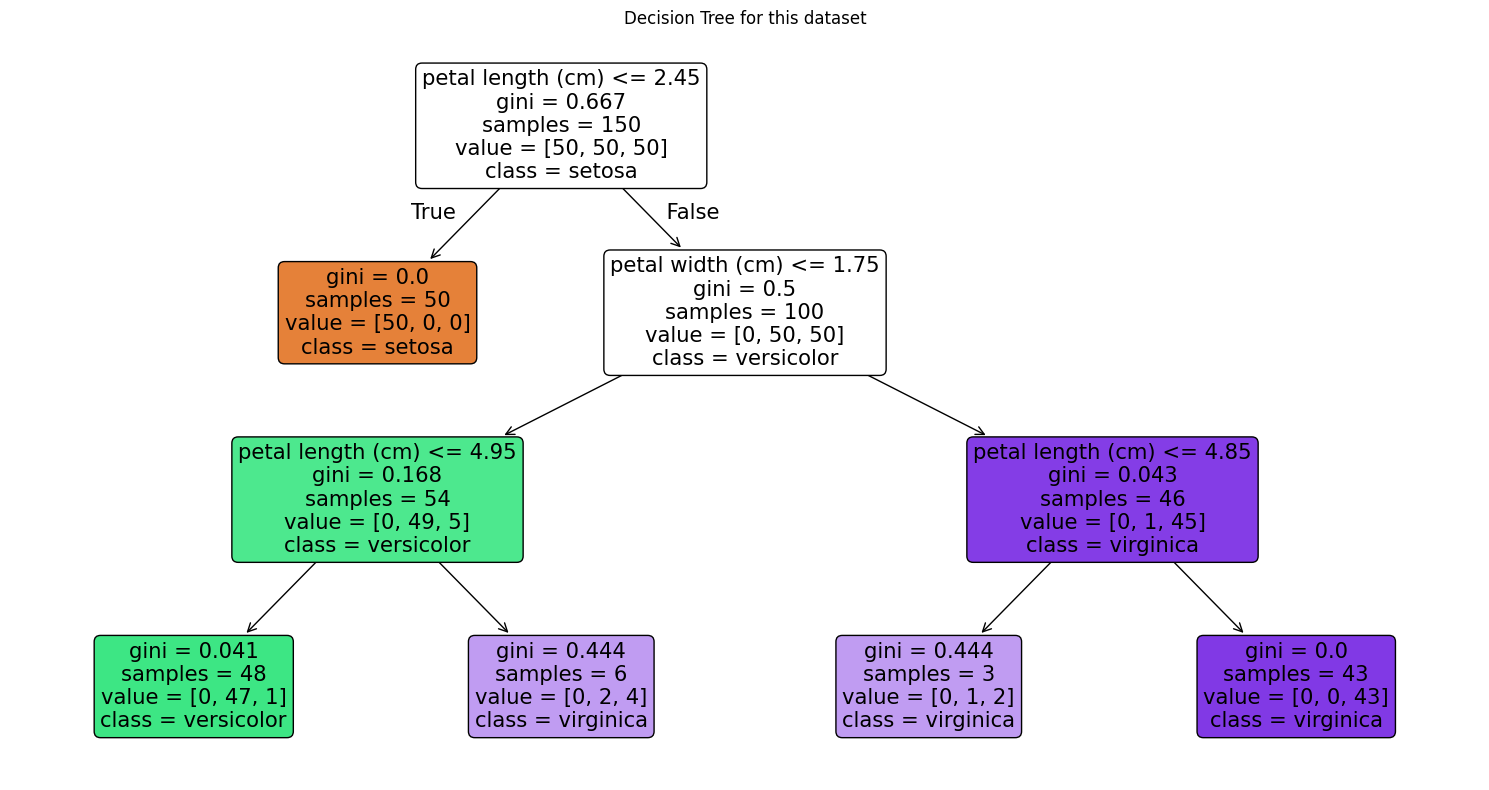

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score,GridSearchCV
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt


#---SKLEARN DECISION TREE

iris = load_iris()
X, y = iris.data, iris.target

tree = DecisionTreeClassifier(max_depth = 3, random_state= 42)
tree.fit(X, y)

scores = cross_val_score(tree, X, y, cv = 5)
print(f"CV Accuracy:- {scores.mean():.2%} +- {scores.std():.2%}")

#feature importance
for name, imp in zip(iris.feature_names, tree.feature_importances_):
  print(f" {name}: {imp:.3f}")

#Hyper parameter tuning

param_grid = {
    'max_depth': [2,3,5,10, None],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,5,10]
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid, cv=5, scoring='accuracy')
grid.fit(X, y)

print(f"Best params: {grid.best_params_}")
print(f"Best CV score: {grid.best_score_:.2%}")

#Visualize the tree
plt.figure(figsize= (15,8))
plot_tree(tree, feature_names= iris.feature_names,
          class_names=iris.target_names, filled=True, rounded=True)
plt.title("Decision Tree for this dataset")
plt.tight_layout()
plt.show()
